1. Problem Definition
2. Import Libraries
3. Load Dataset
4. Initial Data Understanding
5. Data Preprocessing
6. Feature Engineering
7. Exploratory Data Analysis
8. Data Refinement & Final Feature Selection
9. Categorical Encoding
10. Standardization
11. PCA & Explained Variance Analysis
12. K-Means Clustering & Evaluation
13. Agglomerative Clustering & Dendrogram
14. DBSCAN Clustering
15. Clustering Algorithm Comparison
16. PCA 2D Visualization
17. Cluster Profiling
18. Customer Segment Interpretation
19. Business Recommendations
20. Conclusion

# SmartCart Customer Segmentation

## 1. Problem Definition

SmartCart is an e-commerce platform that has collected customer data covering demographics, purchasing behaviour, website activity, and customer response.

The objective is to build an **unsupervised customer segmentation system** that groups customers with similar behavioural patterns.

These customer segments can help SmartCart:
- Develop personalized marketing strategies
- Identify high-value customer groups
- Improve customer retention
- Understand different purchasing and engagement patterns

## 2. Import Libraries

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "9"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Load Dataset

In [2]:
df = pd.read_csv("smartcart_customers.csv")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


## 4. Initial Data Understanding

Before preprocessing, the dataset is inspected to understand its structure, data types, missing values, duplicates, and basic statistical properties.

In [3]:
df.shape

(2240, 22)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [5]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.009375,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.096391,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000


In [6]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.dtypes

ID                       int64
Year_Birth               int64
Education                  str
Marital_Status             str
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer                str
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
Complain                 int64
Response                 int64
dtype: object

## 5. Data Preprocessing

The raw dataset is prepared for further analysis by handling missing values and ensuring that the data is in a suitable format for feature engineering and clustering.

In [9]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [10]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [11]:
df["Dt_Customer"] = pd.to_datetime(
    df["Dt_Customer"],
    dayfirst=True
)

In [12]:
df.dtypes

ID                              int64
Year_Birth                      int64
Education                         str
Marital_Status                    str
Income                        float64
Kidhome                         int64
Teenhome                        int64
Dt_Customer            datetime64[us]
Recency                         int64
MntWines                        int64
MntFruits                       int64
MntMeatProducts                 int64
MntFishProducts                 int64
MntSweetProducts                int64
MntGoldProds                    int64
NumDealsPurchases               int64
NumWebPurchases                 int64
NumCatalogPurchases             int64
NumStorePurchases               int64
NumWebVisitsMonth               int64
Complain                        int64
Response                        int64
dtype: object

## 6. Feature Engineering

To make the customer data more suitable for segmentation, meaningful features are derived from the raw demographic, purchasing, and customer information.

The objective is to create features that better represent:
- Customer demographics
- Customer value and spending behaviour
- Purchase activity and engagement
- Household characteristics
- Customer relationship duration

In [13]:
print("Education:")
print(df["Education"].value_counts())

print("\nMarital Status:")
print(df["Marital_Status"].value_counts())

Education:
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

Marital Status:
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


In [14]:
reference_year = df["Dt_Customer"].dt.year.max()

df["Age"] = reference_year - df["Year_Birth"]

In [15]:
reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (
    reference_date - df["Dt_Customer"]
).dt.days

In [16]:
spending_cols = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

df["Total_Spending"] = df[spending_cols].sum(axis=1)

In [17]:
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [18]:
df["Education"] = df["Education"].replace({
    "Basic": "Undergraduate",
    "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate",
    "PhD": "Postgraduate"
})

In [19]:
df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Partner",
    "Together": "Partner",
    "Single": "Alone",
    "Divorced": "Alone",
    "Widow": "Alone",
    "Absurd": "Alone",
    "YOLO": "Alone"
})

In [20]:
columns_to_drop = [
    "ID",
    "Year_Birth",
    "Dt_Customer",
    "Marital_Status",
    "Kidhome",
    "Teenhome",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

df = df.drop(columns=columns_to_drop)

In [21]:
df.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,57,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,60,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,49,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,30,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,33,161,422,1,Partner


## 7. Exploratory Data Analysis

### 7.1 Feature Distributions

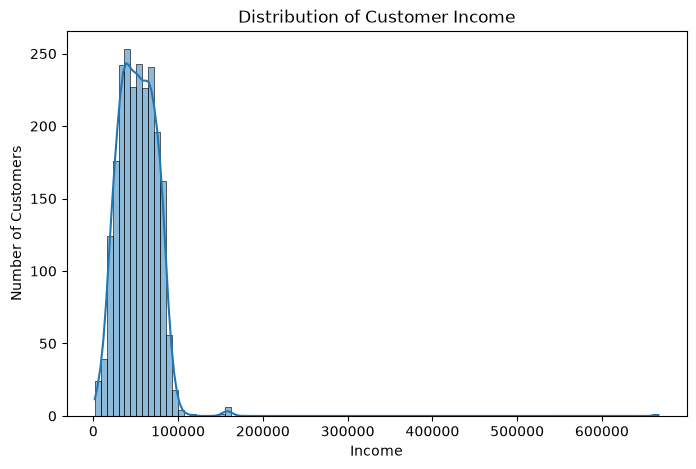

In [22]:
# Income
plt.figure(figsize=(8, 5))

sns.histplot(df["Income"], kde=True)

plt.title("Distribution of Customer Income")
plt.xlabel("Income")
plt.ylabel("Number of Customers")
plt.show()

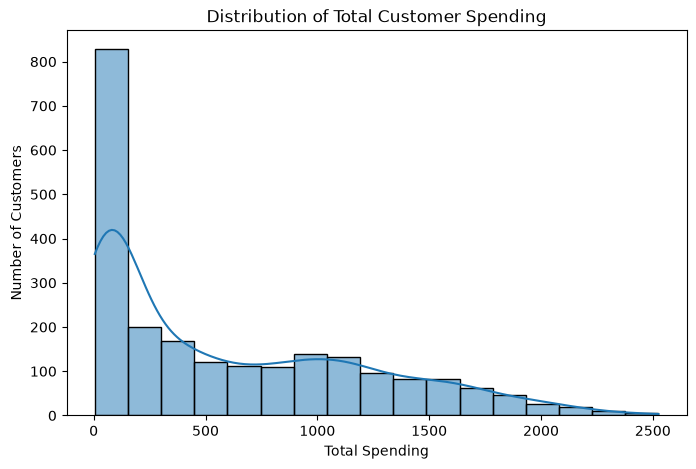

In [23]:
# Total Spending
plt.figure(figsize=(8, 5))

sns.histplot(df["Total_Spending"], kde=True)

plt.title("Distribution of Total Customer Spending")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")
plt.show()

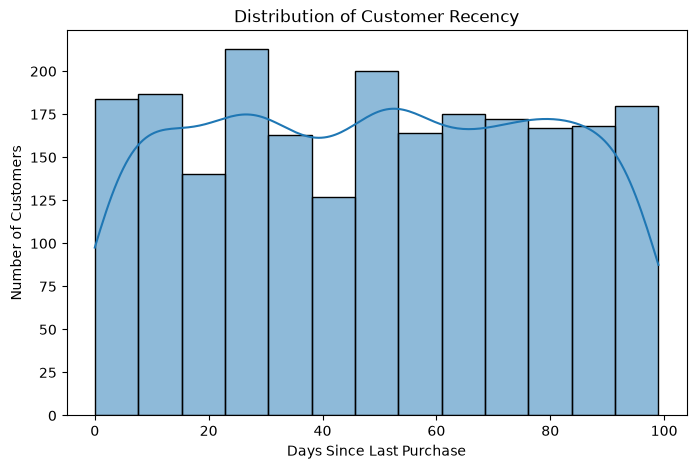

In [24]:
# Recency
plt.figure(figsize=(8, 5))

sns.histplot(df["Recency"], kde=True)

plt.title("Distribution of Customer Recency")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")
plt.show()

### 7.2 Relationships Between Important Features

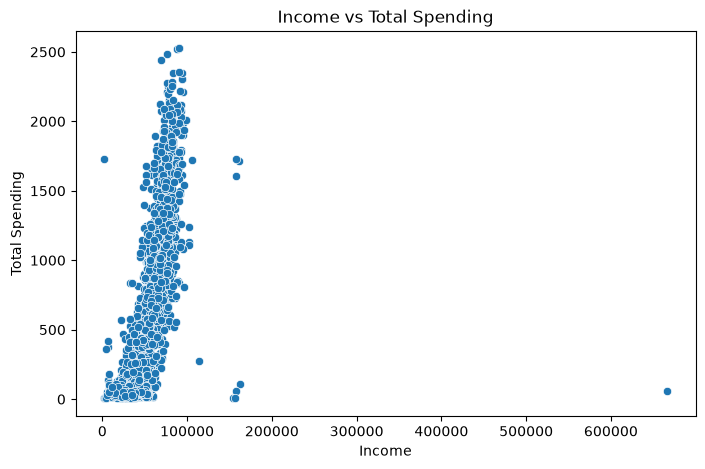

In [25]:
# Income vs Total Spending
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="Income",
    y="Total_Spending",
    data=df
)

plt.title("Income vs Total Spending")
plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.show()

### 7.3 Pairplot for Behavioural Features

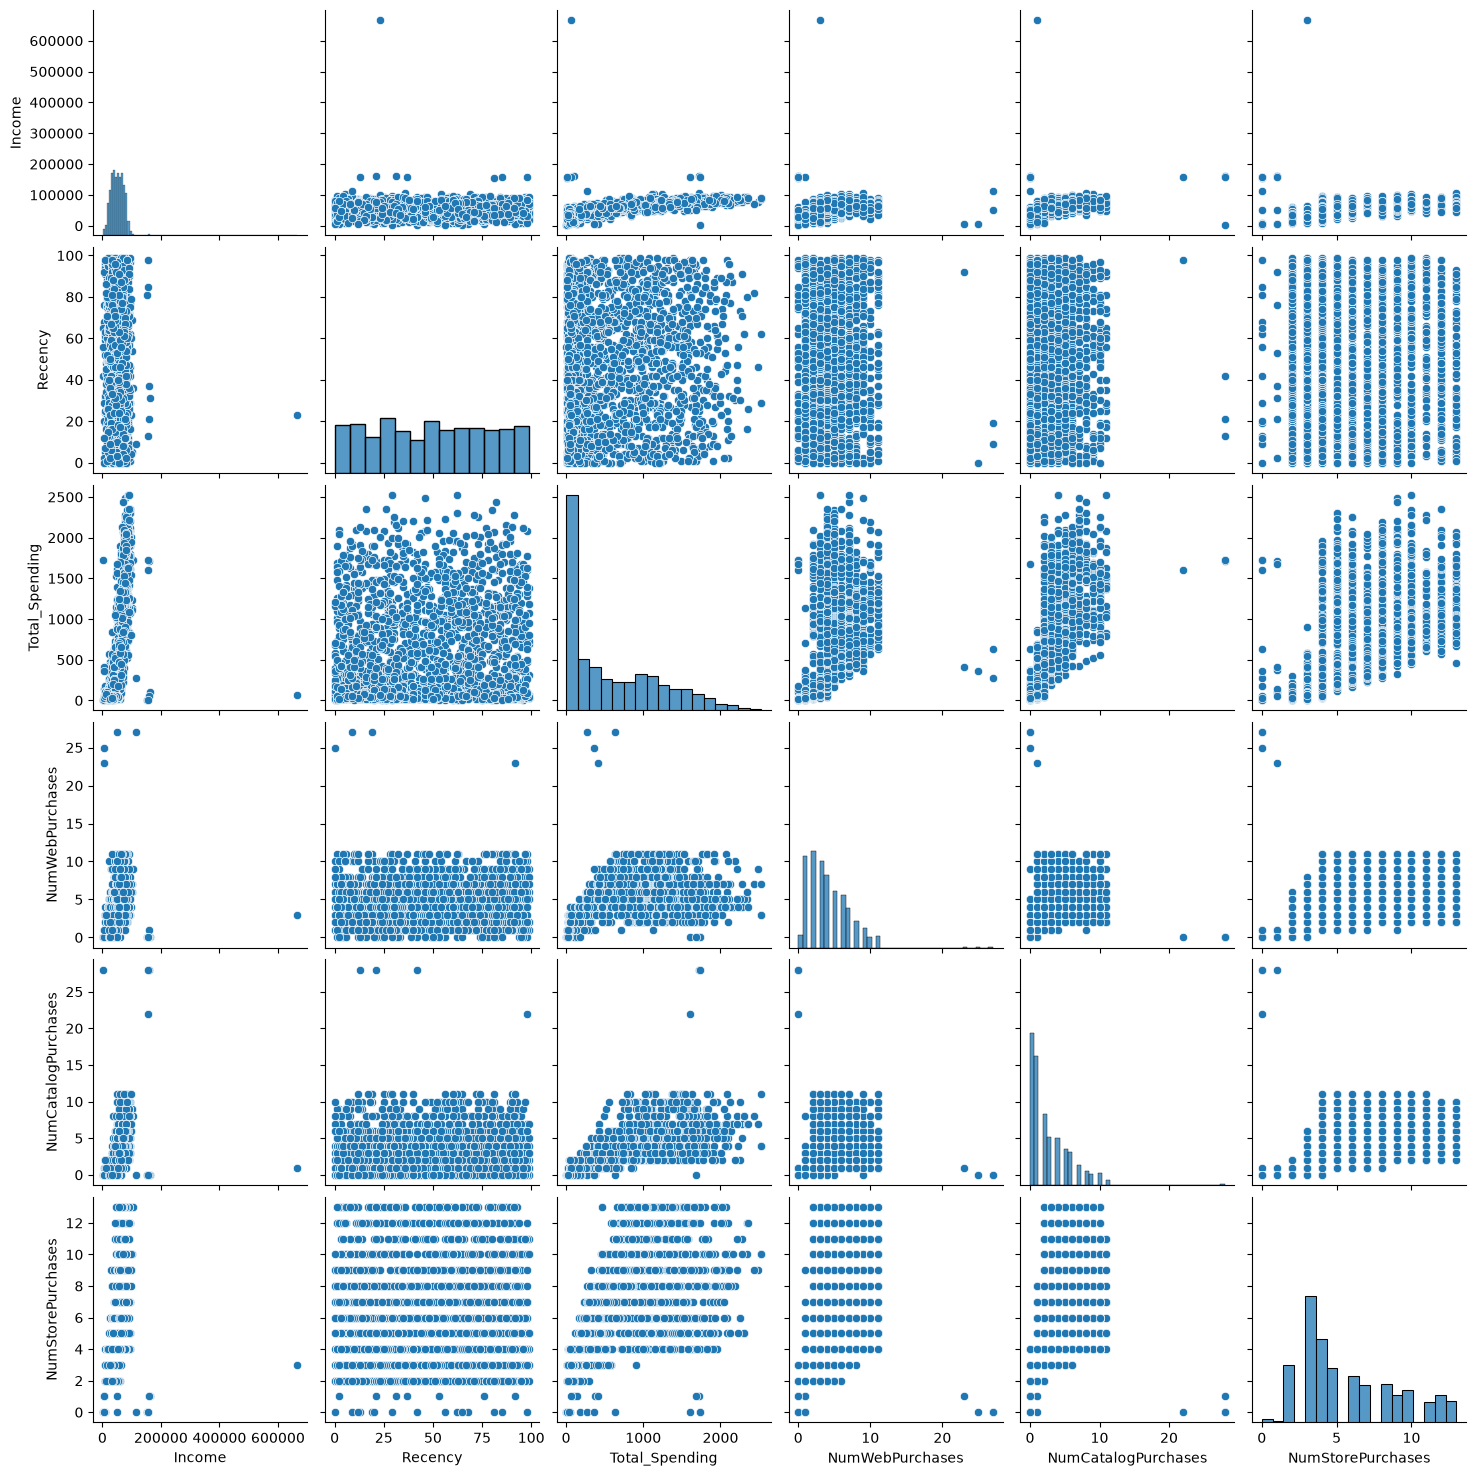

In [26]:
pairplot_cols = [
    "Income",
    "Recency",
    "Total_Spending",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

sns.pairplot(df[pairplot_cols])

plt.show()

## 8. Data Refinement & Final Feature Selection

In [27]:
df = df[
    (df["Income"] < 600_000) &
    (df["Age"] < 90)
].copy()

In [28]:
df.shape

(2236, 15)

### 8.1 Correlation Analysis

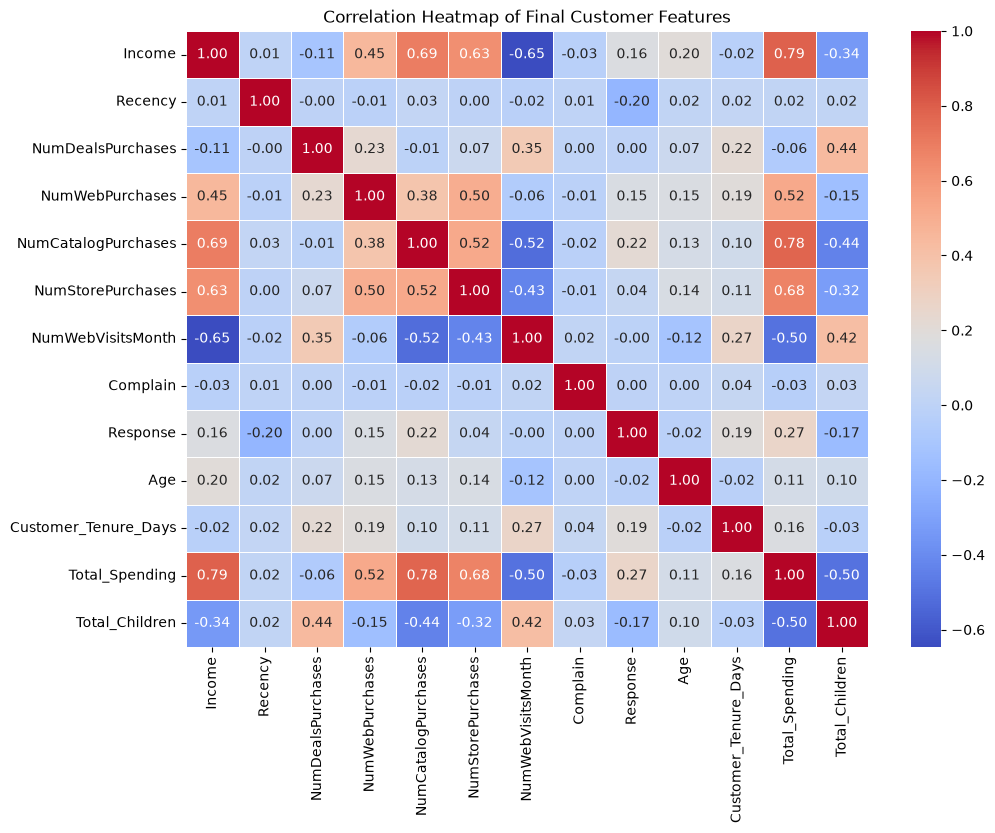

In [29]:
plt.figure(figsize=(11, 8))

correlation = df.select_dtypes(include="number").corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Final Customer Features")
plt.show()

## 9. Categorical Encoding

In [30]:
df_encoded = pd.get_dummies(
    df,
    columns=["Education", "Living_With"],
    dtype=int
)

df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,57,663,1617,0,1,0,0,1,0
1,46344.0,38,2,1,1,2,5,0,0,60,113,27,2,1,0,0,1,0
2,71613.0,26,1,8,2,10,4,0,0,49,312,776,0,1,0,0,0,1
3,26646.0,26,2,2,0,4,6,0,0,30,139,53,1,1,0,0,0,1
4,58293.0,94,5,5,3,6,5,0,0,33,161,422,1,0,1,0,0,1


In [31]:
df_encoded.shape

(2236, 18)

In [32]:
df_encoded.dtypes

Income                     float64
Recency                      int64
NumDealsPurchases            int64
NumWebPurchases              int64
NumCatalogPurchases          int64
NumStorePurchases            int64
NumWebVisitsMonth            int64
Complain                     int64
Response                     int64
Age                          int64
Customer_Tenure_Days         int64
Total_Spending               int64
Total_Children               int64
Education_Graduate           int64
Education_Postgraduate       int64
Education_Undergraduate      int64
Living_With_Alone            int64
Living_With_Partner          int64
dtype: object

# 10. Standardization

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_encoded)

X_scaled.shape

(2236, 18)

## 11. PCA & Explained Variance Analysis

### 11.1 Fit PCA

In [34]:
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

### 11.2 Explained Variance Ratio

In [35]:
explained_variance = pca.explained_variance_ratio_

explained_variance

array([2.31631578e-01, 1.13854539e-01, 1.04058153e-01, 9.91210276e-02,
       7.72999903e-02, 6.45849294e-02, 5.55336167e-02, 5.34428936e-02,
       4.56548592e-02, 3.90182428e-02, 3.36596132e-02, 2.49616300e-02,
       2.21566485e-02, 1.58941458e-02, 1.16135101e-02, 7.51462252e-03,
       5.77596809e-17, 0.00000000e+00])

### 11.3 Cumulative Explained Variance

In [36]:
cumulative_variance = explained_variance.cumsum()
    
cumulative_variance 

array([0.23163158, 0.34548612, 0.44954427, 0.5486653 , 0.62596529,
       0.69055022, 0.74608383, 0.79952673, 0.84518159, 0.88419983,
       0.91785944, 0.94282107, 0.96497772, 0.98087187, 0.99248538,
       1.        , 1.        , 1.        ])

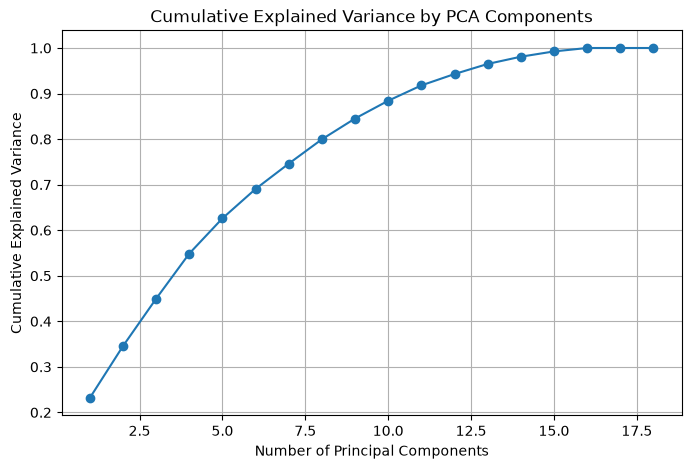

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance by PCA Components")
plt.grid()
plt.show()

### 11.4 3-D visulization

Text(0.5, 0.92, '3d projection')

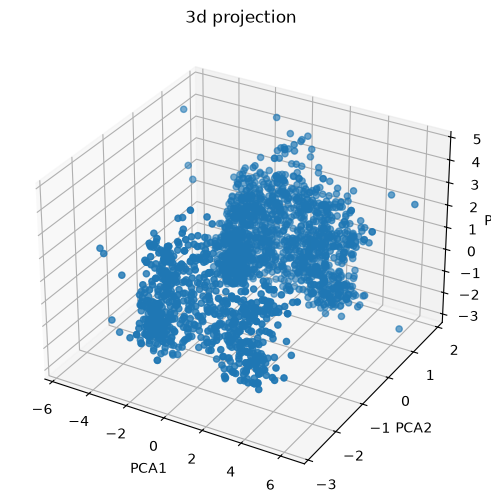

In [38]:
# plot
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

## 12. K-Means Clustering & Evaluation

### 12.1 Elbow Method

In [39]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

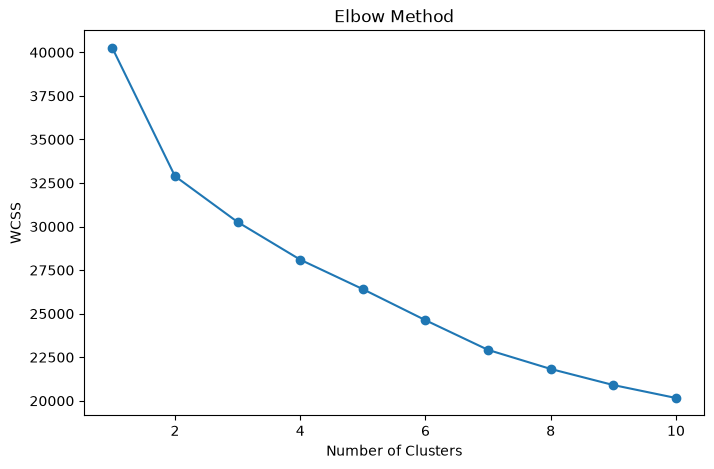

In [40]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [41]:
from kneed import KneeLocator

k_values = range(1, 11)

knee = KneeLocator(
    k_values,
    wcss,
    curve="convex",
    direction="decreasing"
)

print("Knee Point:", knee.knee)

Knee Point: 3


### 12.2 Silhouette Analysis

In [42]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

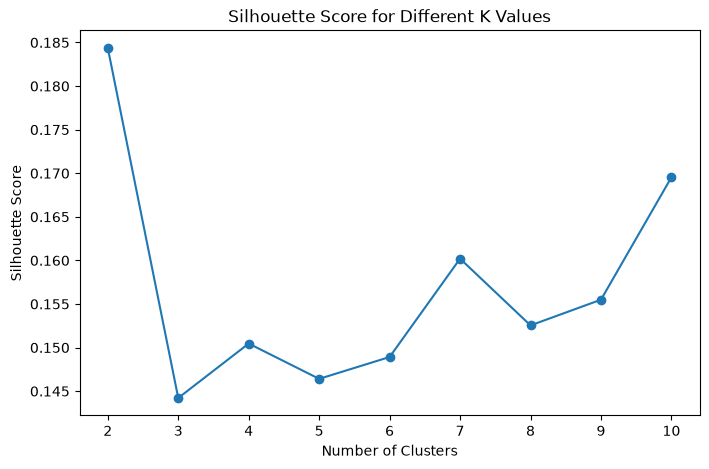

In [43]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.show()

In [44]:
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K={k}: {score:.4f}")

K=2: 0.1844
K=3: 0.1442
K=4: 0.1505
K=5: 0.1464
K=6: 0.1489
K=7: 0.1602
K=8: 0.1525
K=9: 0.1555
K=10: 0.1695


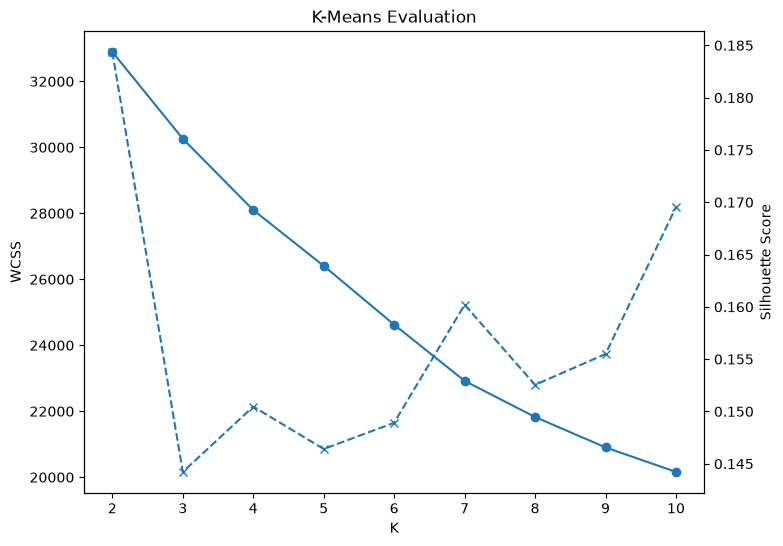

In [45]:
# combined plot

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range, wcss[1:], marker="o")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_scores, marker="x", linestyle="--")
ax2.set_ylabel("Silhouette Score")

plt.title("K-Means Evaluation")
plt.show()

In [46]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

labels_kmeans = kmeans.fit_predict(X_scaled)

print("Cluster Counts:")
print(pd.Series(labels_kmeans).value_counts().sort_index())

Cluster Counts:
0    1263
1     973
Name: count, dtype: int64


Clustering was performed on the full standardized feature space (`X_scaled`) to retain all available customer information. PCA was used separately for visualization.

## 13. Agglomerative Clustering & Dendrogram

In [47]:
from sklearn.cluster import AgglomerativeClustering

agglo = AgglomerativeClustering(n_clusters=2, linkage="ward")

labels_agglo = agglo.fit_predict(X_scaled)

print("Cluster Counts:")
print(pd.Series(labels_agglo).value_counts().sort_index())

Cluster Counts:
0    1357
1     879
Name: count, dtype: int64


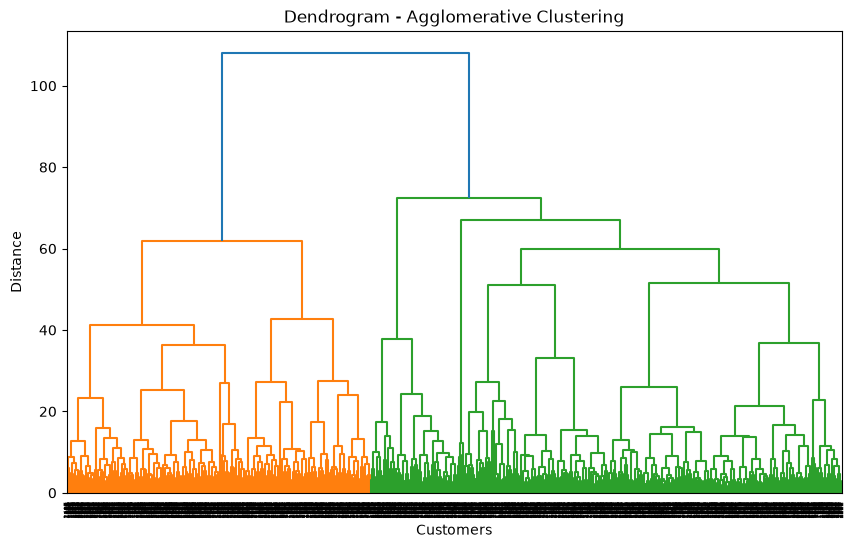

In [48]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title("Dendrogram - Agglomerative Clustering")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

## 14. DBSCAN Clustering

In [49]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(X_scaled)

distances, indices = neighbors.kneighbors(X_scaled)

distances = np.sort(distances[:, 4])

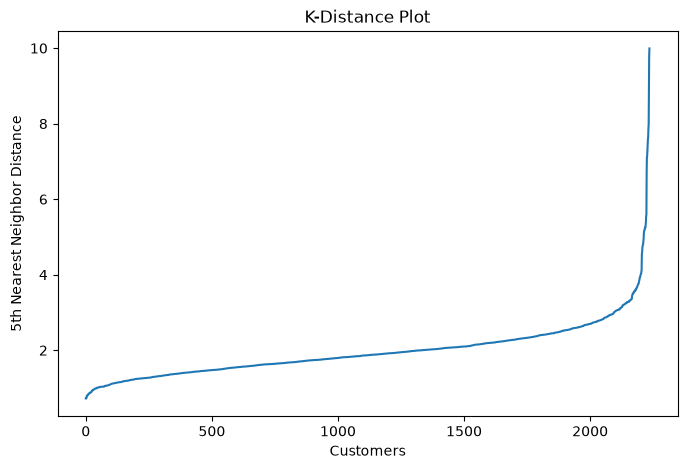

In [50]:
plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.xlabel("Customers")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("K-Distance Plot")
plt.show()

In [51]:
from sklearn.cluster import DBSCAN
    
for eps in [2.2, 2.4, 2.6, 2.8]:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)

    print("eps =", eps)
    print(pd.Series(labels).value_counts().sort_index())
    print()

eps = 2.2
-1     364
 0     292
 1     614
 2     444
 3      12
 4     112
 5     183
 6      43
 7      29
 8      24
 9      17
 10     18
 11      6
 12     17
 13     17
 14      5
 15      5
 16      8
 17      4
 18      4
 19      6
 20      5
 21      7
Name: count, dtype: int64

eps = 2.4
-1     243
 0     313
 1     623
 2     453
 3      32
 4     133
 5     202
 6      49
 7      36
 8      29
 9      29
 10     12
 11     21
 12      6
 13     19
 14     25
 15      5
 16      6
Name: count, dtype: int64

eps = 2.6
-1     149
 0     318
 1     627
 2     463
 3      57
 4     137
 5     207
 6       5
 7      55
 8      40
 9       7
 10     47
 11     29
 12     29
 13     33
 14     26
 15      7
Name: count, dtype: int64

eps = 2.8
-1     105
 0     320
 1     627
 2     468
 3      64
 4     150
 5     211
 6      78
 7      59
 8       7
 9      75
 10     31
 11     37
 12      4
Name: count, dtype: int64



In [52]:
dbscan = DBSCAN(eps=2.8, min_samples=5)

labels_dbscan = dbscan.fit_predict(X_scaled)

print("Cluster Counts:")
print(pd.Series(labels_dbscan).value_counts().sort_index())

Cluster Counts:
-1     105
 0     320
 1     627
 2     468
 3      64
 4     150
 5     211
 6      78
 7      59
 8       7
 9      75
 10     31
 11     37
 12      4
Name: count, dtype: int64


The k-distance plot suggested an eps value around this region. After testing multiple values, eps=2.8 provided a reasonable balance between noise points and cluster formation.

## 15. Clustering Algorithm Comparison

In [53]:
kmeans_score = silhouette_score(X_scaled, labels_kmeans)

In [54]:
agglo_score = silhouette_score(X_scaled, labels_agglo)

In [55]:
mask = labels_dbscan != -1

dbscan_score = silhouette_score(
    X_scaled[mask],
    labels_dbscan[mask]
)

In [56]:
comparison = pd.DataFrame({
    "Algorithm": ["K-Means", "Agglomerative", "DBSCAN"],
    "Clusters": [
        len(set(labels_kmeans)),
        len(set(labels_agglo)),
        len(set(labels_dbscan)) - 1
    ],
    "Noise Points": [
        0,
        0,
        sum(labels_dbscan == -1)
    ],
    "Silhouette Score": [
        kmeans_score,
        agglo_score,
        dbscan_score
    ]
})

comparison

,Algorithm,Clusters,Noise Points,Silhouette Score
0,K-Means,2,0,0.184368
1,Agglomerative,2,0,0.149730
2,DBSCAN,13,105,0.133094


## 16. PCA Visualization

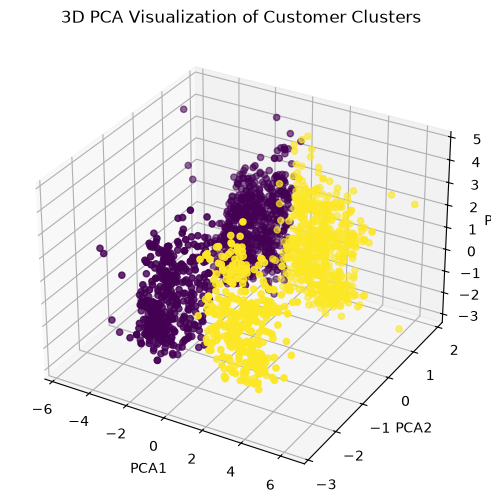

In [58]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    c=labels_kmeans
)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D PCA Visualization of Customer Clusters")

plt.show()

## 17. Cluster Characterization

In [59]:
df["Cluster"] = labels_kmeans

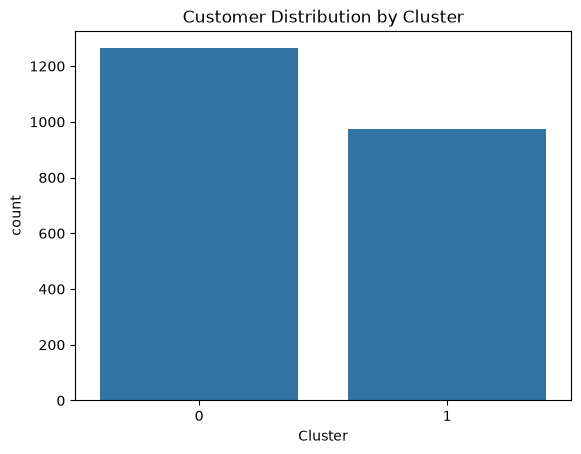

In [60]:
sns.countplot(x="Cluster", data=df)
plt.title("Customer Distribution by Cluster")
plt.show()

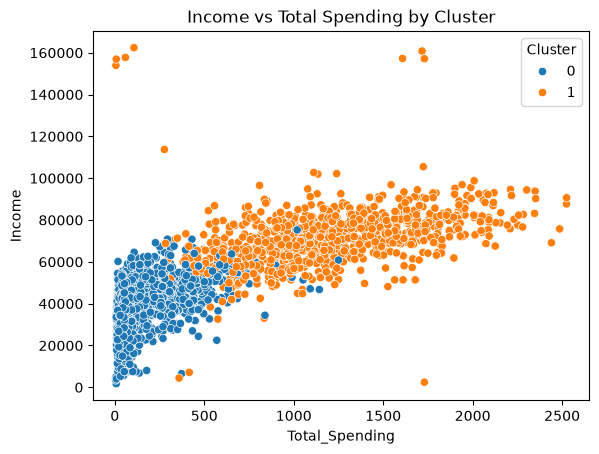

In [61]:
sns.scatterplot(
    x="Total_Spending",
    y="Income",
    hue="Cluster",
    data=df
)

plt.title("Income vs Total Spending by Cluster")
plt.show()

In [62]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)

cluster_summary

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children
Cluster,,,,,,,,,,,,,
0,37351.801663,48.675376,2.552652,2.813143,0.798100,3.711797,6.536025,0.010293,0.097387,43.442597,340.891528,165.405384,1.270784
1,70905.158787,49.688592,2.031860,5.742035,5.084275,8.500514,3.738952,0.007194,0.216855,47.255910,370.494347,1177.881809,0.535457


## 18. Customer Segment Interpretation & Business Recommendations

### Cluster 0 – Low-Value Customers
- Lower average income and total spending.
- Lower purchase activity across web, catalog, and store channels.
- Lower campaign response rate.

**Recommendations:**
- Use targeted discounts and promotional offers to encourage purchases.
- Use personalized campaigns to improve engagement and repeat purchases.

### Cluster 1 – High-Value Customers
- Higher average income and total spending.
- Higher purchase activity across web, catalog, and store channels.
- Higher campaign response rate.

**Recommendations:**
- Focus on retention through loyalty programs and exclusive offers.
- Provide personalized recommendations and premium promotions.

Overall, SmartCart can use these segments to apply targeted marketing strategies instead of using the same approach for all customers.

## 19. Conclusion

The SmartCart customer dataset was analyzed using unsupervised machine learning to identify meaningful customer segments based on purchasing behavior, engagement, and customer characteristics.

The data was cleaned, relevant features were engineered, categorical variables were encoded, and numerical features were standardized before applying clustering algorithms.

K-Means, Agglomerative Clustering, and DBSCAN were evaluated and compared. K-Means with two clusters provided the most suitable broad segmentation based on the clustering evaluation results.

The final segmentation identified two major customer groups: lower-value customers with relatively low spending and purchase activity, and higher-value customers with higher income, spending, and purchasing activity.

These segments can help SmartCart design more targeted marketing, retention, and engagement strategies.